# This notebook is used to plot curvefit for the subtlety data (april sess 1 and 2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import ttest_rel,wilcoxon
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
import os

In [2]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [3]:
path_to_add = os.path.abspath('../')
path_to_add

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code'

In [4]:
sys.path.append(path_to_add)
from func_curvefit import *
import seaborn as sns

In [5]:
# root_data_file = '../../data/subtlety_data'
root_folder = '../../data/subtlety_data/'

In [6]:
## import dataframes (curvefit)
curvefit_ses1 = pd.read_csv(f'{root_folder}/curve_fit_subt_ses1/all_params_1k_subt.csv')#merged_apr_ses1.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:] # has bad subs

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
13,15.0,0.907114,0.103089,-27.810296,0.534505,NaN,0.201028,0.543434,0.218639,0.525000,0.193333,False
39,43.0,0.874909,0.113754,-26.431992,0.408599,NaN,0.221992,0.579153,0.144244,0.531667,0.121667,False
88,100.0,0.981739,0.053964,-36.872079,0.423466,NaN,0.127252,0.526937,0.181588,0.516364,0.178333,False
117,132.0,0.988484,0.044332,-39.624762,0.470592,NaN,0.108652,0.527985,0.183901,0.524167,0.181667,False
124,139.0,0.990811,0.040039,-41.050748,0.375244,NaN,0.059265,0.503770,0.250840,0.503333,0.250833,False
129,146.0,0.979431,0.057878,-35.891859,0.525861,NaN,0.084023,0.553146,0.110361,0.552500,0.109167,False
137,154.0,0.984955,0.049049,-38.209221,0.388454,-0.054971,0.084176,0.502281,0.015341,0.497500,0.015000,False
139,156.0,0.993094,0.034272,-43.228128,0.357062,NaN,0.075175,0.569330,0.026745,0.565833,0.026667,False
173,193.0,0.940653,0.088831,-29.894283,0.447231,NaN,0.159722,0.657455,0.209443,0.649091,0.205000,False
207,229.0,0.989475,0.043020,-40.045226,0.338155,NaN,0.109512,0.580672,0.021820,0.562500,0.020833,False


# clean data

In [7]:
curvefit_ses1 = fix_obj_center(curvefit_ses1)
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:] # bad subs bc of obj_center removed

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped


In [8]:
curvefit_ses1 = add_new_params(curvefit_ses1)
curvefit_ses1.loc[curvefit_ses1['range']<0,:] # no neg amp subs

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [9]:
curvefit_ses1.rename(columns={'obj_center':'PSE','center':'subj_center'},inplace=True) # rename obj_center

In [10]:
np.where(curvefit_ses1['bias_xmin']<0), np.where(curvefit_ses1['bias_xmax']<0)

((array([], dtype=int64),), (array([], dtype=int64),))

In [12]:
curvefit_ses1.head()

,subID,r_squared,nrmse,aic,subj_center,PSE,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
0,1.0,0.998083,0.018623,-51.767137,0.354384,0.326204,0.091967,0.175069,0.036553,0.158333,0.035833,False,0.788378,0.827272
1,2.0,0.994396,0.030065,-45.061484,0.395356,0.379090,0.106477,0.092967,0.003165,0.070833,0.000000,False,0.903868,0.967075
2,3.0,0.991012,0.035994,-42.541465,0.496416,0.436420,0.131643,0.291980,0.163815,0.279167,0.151667,False,0.544205,0.640594
3,4.0,0.990862,0.036692,-42.272749,0.353184,0.288929,0.114098,0.322398,0.147745,0.298333,0.145833,False,0.529857,0.685745
4,5.0,0.976299,0.064073,-34.468260,0.537650,0.506901,0.093353,0.165036,0.036492,0.162500,0.030833,False,0.798472,0.818923


# plot histograms of the good data

In [33]:
imp_cols = ['PSE','range','bias','sigma', 'subj_center','bias_xmin','bias_xmax']

In [56]:
ticks_all = {'PSE':[0,0.3,0.6],'range':[0,0.5,1],'bias':[0,0.5,1]}

In [62]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

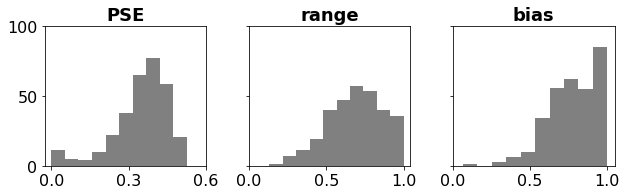

In [63]:
fig,axs=plt.subplots(figsize=(9,3),ncols=len(imp_cols[:3]),nrows=1,sharey=True)
for i,col in enumerate(imp_cols[:3]):
    ax = axs[i]
    if i<3:
        ax.hist(curvefit_ses1[col], color = 'grey')
    else:
        ax.hist(curvefit_ses1[col], color = [.8,.8,.8])
    ax.set_title(col,fontweight='bold',fontsize=18)
    ax.set_xticks(ticks_all[col])
    ax.set_ylim(0,100)
    if i == 0:
        ax.set_yticks([0,50,100])
plt.tight_layout()
plt.savefig('../../results/subtlety/params_histogram_subt.png',dpi=300)

In [54]:
s=18 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [68]:
ticks_all = {'sigma':[0,0.15,0.3],'subj_center':[0.2,0.4,0.6],'bias_xmin':[0,0.4,0.8],'bias_xmax':[0,0.15,0.3]}

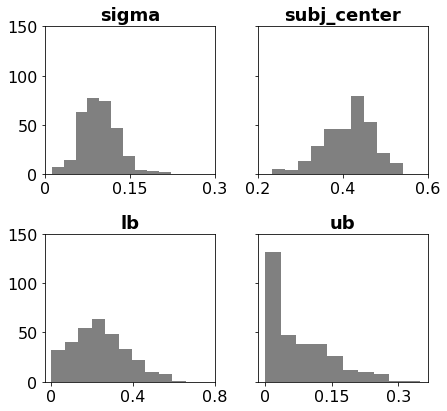

In [73]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3.25*int(len(imp_cols[3:])/2),3*int(len(imp_cols[3:])/2)),sharey=True)
for i,col in enumerate(imp_cols[3:]):
    r = int(np.floor(i/2))
    c = i%2
    ax = axs[r,c]
    ax.hist(curvefit_ses1[col], color =  'grey')#[.8,.8,.8])
    if col == 'bias_xmin':
        title = 'lb'
    elif col == 'bias_xmax':
        title = 'ub'
    else:
        title = col
    ax.set_title(title,fontweight='bold',fontsize=18)
    ax.set_ylim(0,150)
    ax.set_xticks(ticks_all[col])
    limits = [ax.get_xlim()[0],ax.get_xlim()[1]]
    ax.set_xlim(limits)
    ticks = ticks_all[col]
    ticklabels = []
    for t in ticks:
        ticklabels.append(str(t))
    ax.set_xticks(ticks,ticklabels)
plt.tight_layout()
plt.savefig('../../results/subtlety/params_histogram_subt_extra.png',dpi=300)